In [13]:
# === SETUP: Run this first! ===
import os
import sys

# Change to project root and add to Python path
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)  # Goes up one level from 'notebooks/'
os.chdir(project_root)
sys.path.insert(0, project_root)

print(f"Project root: {project_root}")
print(f"tsnn module path: {os.path.join(project_root, 'tsnn')}")

Project root: /home/ubuntu
tsnn module path: /home/ubuntu/tsnn


In [14]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, RidgeCV, LinearRegression
import torch
from torch.utils.data import Dataset, random_split
from torch.utils.data import DataLoader
import importlib
import sys
#sys.path.append('/Users/cyrilgarcia/notebooks/tsnn/')

import tsnn

from tsnn.generators import generators
from tsnn.benchmarks import benchmark_comparison, ml_benchmarks, torch_benchmarks
from tsnn import utils
import torch.nn.functional as F
import math
from typing import Optional
from tsnn.tstorch import transformers



plt.style.use('ggplot')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
from dataclasses import dataclass
from torch import nn


In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")

Using device: cuda
GPU name: Tesla T4
Number of GPUs: 1


In [17]:
from typing import Dict

In [18]:
from tsnn.tstorch import models

In [19]:
from tsnn.tstorch.models import GlobalMLP, BiDimensionalMLP, OneDimensionalTransformer, CustomBiDimensionalTransformer
from sklearn.ensemble import HistGradientBoostingRegressor



# Summary

In [8]:
# In this notebook we will run the experiments to generate the figures for the paper.

# Test dataset

In [9]:
# We work with the following data.

In [10]:
# Global parameters
T_max = 5000
N1 = 10
F1 = 20
T1 = 5 # This parameter will be the n_rolling

print(T_max, N1, F1, T1)

5000 10 20 5


In [11]:
def generate_synthetic_datasets(
    num_time_steps: int = 3000,
    num_time_series: int = 10,
    num_features: int = 10,
    low_corr: float = 0.1,
    high_corr: float = 0.2,
    pct_zero_corr: float = 0.5,
) -> Dict[str, "generators.Generator"]:
    """
    Generates 5 synthetic multivariate time series datasets with different
    types of cross-series dependencies.

    Returns
    -------
    dict
        Keys: "d_lin", "d_cond", "d_shift", "d_cs", "d_cs_shift", "d_all"
        Values: generators.Generator objects (already with .train and .test)
    """
    dic_data = {}

    # Helper to avoid repeating the same 10 lines
    def make_gen(split_conditional=0.0,
                 split_shift=0.0,
                 split_seasonal=0.0,
                 split_cs=0.0,
                 split_cs_shift=0.0):
        gen = generators.Generator(num_time_steps, num_time_series, num_features)
        gen.generate_dataset(
            pct_zero_corr=pct_zero_corr,
            split_conditional=split_conditional,
            split_shift=split_shift,
            split_seasonal=split_seasonal,
            split_cs=split_cs,
            split_cs_shift=split_cs_shift,
            low_corr=low_corr,
            high_corr=high_corr,
        )
        return gen

    dic_data["d_lin"] = make_gen()

    # 1. Pure conditional (causal) dependence
    dic_data["d_cond"] = make_gen(split_conditional=1.0)

    # 2. Pure lagged (time-shifted) dependence
    dic_data["d_shift"] = make_gen(split_shift=1.0)

    # 3. Pure contemporaneous cross-sectional correlation
    dic_data["d_cs"] = make_gen(split_cs=1.0)

    # 4. Contemporaneous + lagged cross-series
    dic_data["d_cs_shift"] = make_gen(split_cs_shift=1.0)

    # 5. Equal mix of all four mechanisms
    dic_data["d_all"] = make_gen(
        split_conditional=0.2,
        split_shift=0.2,
        split_cs=0.2,
        split_cs_shift=0.2,
    )

    return dic_data

In [12]:
# list_low_corr = [0.01, 0.025, 0.05, 0.1]
# list_high_corr = [2*x for x in list_low_corr]

list_low_corr = [0.01, 0.03, 0.05, 0.1, 0.3]
list_high_corr = list_low_corr

dic_data = {}

for i in range(len(list_low_corr)):
    name = "correl" + str(list_low_corr[i])
    dic_data[name] = generate_synthetic_datasets(num_time_steps=T_max, num_time_series=N1, num_features=F1, low_corr=list_low_corr[i], high_corr=list_high_corr[i])
    

In [13]:
dic_data.keys()

dict_keys(['correl0.01', 'correl0.03', 'correl0.05', 'correl0.1', 'correl0.3'])

In [14]:
effects = list(dic_data['correl0.1'].keys())
print(effects)

['d_lin', 'd_cond', 'd_shift', 'd_cs', 'd_cs_shift', 'd_all']


In [15]:
# We will fix the above dataset for now.

In [16]:
def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx

def build_attention_mask(mask_fn, seq_len, device="cpu"):
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device)
    h = torch.zeros(1, device=device)
    mask_bool = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])  # (seq_len, seq_len)
    return mask_bool

mask = causal_mask
mask = build_attention_mask(mask, T1, device=device)
def custom_mask_mod(b, h, q_idx, kv_idx):
    return mask[q_idx, kv_idx]

# List of models

In [9]:
# Let's list here all the models we wish to test on all the data.

In [10]:
def get_models():
    MLP_global = GlobalMLP(N1, F1, T1, dropout=0.2).to(device)

    MLP_2D = BiDimensionalMLP(N1, F1, T1, dropout=0.2).to(device)

    trans_1D_T4 = OneDimensionalTransformer(N1, F1, T1, mask=mask, attn_direction="T",  num_attn_layers=4,
                                            dropout=0.2, roll_y=True).to(device)
    #Note: using the MLP compression seems very bad..

    trans_2D_TCTC = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask, layers='TCTC',
                                                                        dropout=0.05, d_model=128, dim_feedforward=128*4, sparsify=None, 
                                                                               roll_y=True).to(device)

    trans_2D_TCTCTCTC = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask, layers='TCTCTCTC',
                                                                        dropout=0.05, d_model=128, dim_feedforward=128*4, sparsify=None, 
                                                                               roll_y=True).to(device)


    dic_models = {'MLP_global':MLP_global, 'MLP_2D':MLP_2D, "trans_1D_T4":trans_1D_T4, "trans_2D_TCTC":trans_2D_TCTC, "trans_2D_TCTCTCTC":trans_2D_TCTCTCTC}

    trans_2D_TCTC_rollfalse = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask, layers='TCTC',
                                                                        dropout=0.05, d_model=128, dim_feedforward=128*4, sparsify=None, 
                                                                               roll_y=False).to(device)

    trans_2D_TCTCTCTC_rollfalse = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask, layers='TCTCTCTC',
                                                                        dropout=0.05, d_model=128, dim_feedforward=128*4, sparsify=None, 
                                                                               roll_y=False).to(device)


    dic_models_rollfalse = {"trans_2D_TCTC":trans_2D_TCTC_rollfalse, "trans_2D_TCTCTCTC":trans_2D_TCTCTCTC_rollfalse}
    
    return dic_models, dic_models_rollfalse

In [11]:
# For each model we also need to specify the option we will use to fit them.

In [12]:
dic_data['correl0.1']

NameError: name 'dic_data' is not defined

In [21]:
dic_data.keys()

dict_keys(['correl0.01', 'correl0.03', 'correl0.05', 'correl0.1', 'correl0.3'])

# Running on a single model

In [20]:
# Global parameters
T_max = 5000
N1 = 500
F1 = 50
T1 = 5 # This parameter will be the n_rolling

print(T_max, N1, F1, T1)

5000 500 50 5


In [21]:
def generate_synthetic_datasets(
    num_time_steps: int = 3000,
    num_time_series: int = 10,
    num_features: int = 10,
    low_corr: float = 0.1,
    high_corr: float = 0.2,
    pct_zero_corr: float = 0.5,
) -> Dict[str, "generators.Generator"]:
    """
    Generates 5 synthetic multivariate time series datasets with different
    types of cross-series dependencies.

    Returns
    -------
    dict
        Keys: "d_lin", "d_cond", "d_shift", "d_cs", "d_cs_shift", "d_all"
        Values: generators.Generator objects (already with .train and .test)
    """
    dic_data = {}

    # Helper to avoid repeating the same 10 lines
    def make_gen(split_conditional=0.0,
                 split_shift=0.0,
                 split_seasonal=0.0,
                 split_cs=0.0,
                 split_cs_shift=0.0):
        gen = generators.Generator(num_time_steps, num_time_series, num_features)
        gen.generate_dataset(
            pct_zero_corr=pct_zero_corr,
            split_conditional=split_conditional,
            split_shift=split_shift,
            split_seasonal=split_seasonal,
            split_cs=split_cs,
            split_cs_shift=split_cs_shift,
            low_corr=low_corr,
            high_corr=high_corr,
        )
        return gen

    dic_data["d_lin"] = make_gen()

    # 1. Pure conditional (causal) dependence
    dic_data["d_cond"] = make_gen(split_conditional=1.0)

    # 2. Pure lagged (time-shifted) dependence
    dic_data["d_shift"] = make_gen(split_shift=1.0)

    # 3. Pure contemporaneous cross-sectional correlation
    dic_data["d_cs"] = make_gen(split_cs=1.0)

    # 4. Contemporaneous + lagged cross-series
    dic_data["d_cs_shift"] = make_gen(split_cs_shift=1.0)

    # 5. Equal mix of all four mechanisms
    dic_data["d_all"] = make_gen(
        split_conditional=0.2,
        split_shift=0.2,
        split_cs=0.2,
        split_cs_shift=0.2,
    )

    return dic_data

In [22]:
# list_low_corr = [0.01, 0.025, 0.05, 0.1]
# list_high_corr = [2*x for x in list_low_corr]

#list_low_corr = [0.01, 0.03, 0.05, 0.1, 0.3]
list_low_corr = [0.1]
list_high_corr = list_low_corr

dic_data = {}

for i in range(len(list_low_corr)):
    name = "correl" + str(list_low_corr[i])
    dic_data[name] = generate_synthetic_datasets(num_time_steps=T_max, num_time_series=N1, num_features=F1, low_corr=list_low_corr[i], high_corr=list_high_corr[i])
    

In [23]:
dic_data.keys()

dict_keys(['correl0.1'])

In [24]:
effects = list(dic_data['correl0.1'].keys())
print(effects)

['d_lin', 'd_cond', 'd_shift', 'd_cs', 'd_cs_shift', 'd_all']


In [25]:
# We will fix the above dataset for now.

In [26]:
def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx

def build_attention_mask(mask_fn, seq_len, device="cpu"):
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device)
    h = torch.zeros(1, device=device)
    mask_bool = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])  # (seq_len, seq_len)
    return mask_bool

mask = causal_mask
mask = build_attention_mask(mask, T1, device=device)
def custom_mask_mod(b, h, q_idx, kv_idx):
    return mask[q_idx, kv_idx]

In [27]:
# Lets test what are the parameters we need to set to increase the size of the model.

In [28]:
noise_level = 'correl0.1'
effect1 = 'd_cond'

100%|██████████| 20/20 [20:39<00:00, 62.00s/it]


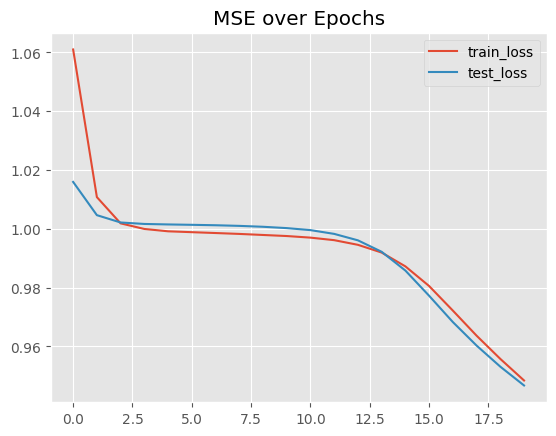

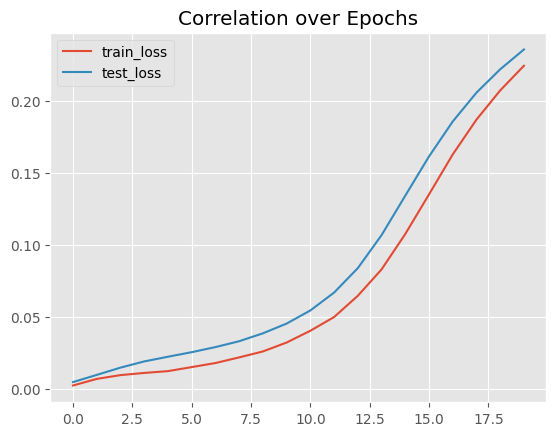

,true,optimal,conditional
optimal,0.446,nan,nan
conditional,0.446,1.000,nan
model1,0.250,0.533,0.533


,true,optimal,conditional
optimal,0.448,nan,nan
conditional,0.448,1.000,nan
model1,0.235,0.528,0.528


In [29]:

z = dic_data[noise_level][effect1]
z.get_dataloader(n_rolling=T1, roll_y=True, batch_size=32)
            
lr=0.001/2
            

epochs = 20
#epochs = 2
model = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask, layers='TCTC',
                                                                        dropout=0.05, d_model=128, dim_feedforward=128*4, sparsify=None, 
                                                                               roll_y=True).to(device)

          

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
wrapper = torch_benchmarks.TorchWrapper(model, optimizer=optimizer, device=device)


# Train
wrapper.fit(z.train, test=z.test, epochs=epochs, plot=True, grad_accum_steps=8)

# Compare
comp = benchmark_comparison.Comparator(models=[wrapper], model_names=["model1"])

corr_train = comp.correl(z, mode="train", return_values=True)
corr_test  = comp.correl(z, mode="test",  return_values=True)

train_corr = corr_train.loc["model1", "optimal"]
test_corr  = corr_test.loc["model1", "optimal"]

display(comp.correl(z, mode='train'))
display(comp.correl(z, mode='test'))

# Function to create table for an effect

In [22]:
# We give the function that creates for a given effect the table testing all models and all noise level.

In [23]:
def run_models(effect1):

    # Storage
    records_train = []
    records_test  = []

    for noise_level in dic_data.keys():
        
        z = dic_data[noise_level][effect1]
        z.get_dataloader(n_rolling=T1)

        dic_models, dic_models_rollfalse = get_models()


        lasso_full = ml_benchmarks.CustomBenchmarkRolling(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                                verbose=False, max_iter=2000, selection='random', n_jobs=5, cv=3))
        lasso_full.fit(z.train)
        boost_model = ml_benchmarks.CustomBenchmarkRolling(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, n_iter_no_change=100))
        boost_model.fit(z.train)

        comp = benchmark_comparison.Comparator(models=[lasso_full, boost_model], model_names=['lasso_full', 'boosting'])
        corr_train = comp.correl(z, mode="train", return_values=True)
        corr_test  = comp.correl(z, mode="test",  return_values=True)

        # Save results
        records_train.append({
            "noise_level": noise_level,
            "model": 'lasso_full',
            "train_corr_optimal": corr_train.loc['lasso_full', "optimal"]
        })
        records_test.append({
            "noise_level": noise_level,
            "model": 'lasso_full',
            "test_corr_optimal": corr_test.loc['lasso_full', "optimal"]
        })

        records_train.append({
            "noise_level": noise_level,
            "model": 'boosting',
            "train_corr_optimal": corr_train.loc['boosting', "optimal"]
        })
        records_test.append({
            "noise_level": noise_level,
            "model": 'boosting',
            "test_corr_optimal": corr_test.loc['boosting', "optimal"]
        })
        


        for model_key in dic_models.keys():                   
            print(f"Running → {noise_level} | {model_key}")

            z = dic_data[noise_level][effect1]
            if model_key in ["trans_1D_T4", "trans_2D_TCTC", "trans_2D_TCTCTCTC"]:
                z.get_dataloader(n_rolling=T1, roll_y=True)
            else:
                z.get_dataloader(n_rolling=T1)

            if model_key in ["trans_2D_TCTC", "trans_2D_TCTCTCTC"]:
                lr=0.001/2
            else:
                lr=0.001

            epochs = 20
            if noise_level in ['correl0.01', 'correl0.03']:
                epochs = 40

            model = dic_models[model_key]

            # Model
            if noise_level == 'correl0.01' and model_key in ["trans_2D_TCTC", "trans_2D_TCTCTCTC"]:
                z.get_dataloader(n_rolling=T1)
                model = dic_models_rollfalse[model_key]
                epochs = 60
                lr=0.0001

            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            wrapper = torch_benchmarks.TorchWrapper(model, optimizer=optimizer, device=device)

            
            # Train
            wrapper.fit(z.train, test=z.test, epochs=epochs, plot=False)

            # Compare
            comp = benchmark_comparison.Comparator(models=[wrapper], model_names=["model1"])

            corr_train = comp.correl(z, mode="train", return_values=True)
            corr_test  = comp.correl(z, mode="test",  return_values=True)

            train_corr = corr_train.loc["model1", "optimal"]
            test_corr  = corr_test.loc["model1", "optimal"]

            # Save results
            records_train.append({
                "noise_level": noise_level,
                "model": model_key,
                "train_corr_optimal": train_corr
            })
            records_test.append({
                "noise_level": noise_level,
                "model": model_key,
                "test_corr_optimal": test_corr
            })

    # ————————————————————————————————————————
    # 3. Convert to nice DataFrames
    # ————————————————————————————————————————
    df_train = pd.DataFrame(records_train)
    df_test  = pd.DataFrame(records_test)

    # Pivot: rows = noise level, columns = effect type
    train_pivot = df_train.pivot(index="noise_level", columns="model", values="train_corr_optimal")
    test_pivot  = df_test.pivot(index="noise_level", columns="model", values="test_corr_optimal")

    col_order = ["lasso_full", "boosting"] + list(dic_models.keys())
    train_pivot = train_pivot[col_order]
    test_pivot  = test_pivot[col_order]

    return train_pivot, test_pivot

## Running on linear effect

In [24]:
dic_models, dic_models_rollfalse = get_models()

table_train_lin0, table_test_lin0 = run_models('d_lin')

Running → correl0.01 | MLP_global


100%|██████████| 40/40 [00:06<00:00,  6.12it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | MLP_2D


100%|██████████| 40/40 [00:10<00:00,  3.97it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | trans_1D_T4


...

100%|██████████| 20/20 [00:08<00:00,  2.33it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTC


100%|██████████| 20/20 [00:24<00:00,  1.20s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTCTCTC


100%|██████████| 20/20 [00:44<00:00,  2.23s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [25]:
display(table_train_lin0.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

model,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC,trans_2D_TCTCTCTC
noise_level,,,,,,,
correl0.01,0.020,0.014,0.032,0.032,0.034,0.182,0.115
correl0.03,0.023,0.026,0.102,0.101,0.109,0.133,0.090
correl0.05,0.053,0.043,0.157,0.157,0.198,0.473,0.337
correl0.1,0.132,0.072,0.316,0.329,0.376,0.732,0.606
correl0.3,0.301,0.197,0.708,0.745,0.791,0.973,0.981


In [26]:
display(table_test_lin0.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

model,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC,trans_2D_TCTCTCTC
noise_level,,,,,,,
correl0.01,0.016,-0.007,0.054,0.037,0.046,0.166,0.131
correl0.03,0.014,-0.005,0.158,0.113,0.165,0.160,0.106
correl0.05,0.042,0.006,0.216,0.202,0.260,0.492,0.364
correl0.1,0.114,0.034,0.432,0.454,0.478,0.740,0.639
correl0.3,0.304,0.181,0.817,0.851,0.840,0.974,0.982


In [27]:
# Saving the data

table_train_lin0.to_csv('table_train_lin.csv', index=True)
table_test_lin0.to_csv('table_test_lin.csv', index=True)

In [ ]:
# Later (even in a new notebook/session)
# table_train_lin0 = pd.read_csv('table_train_lin0.csv', index_col=0)
# table_train_lin0.head()

## Running on conditional effect

In [29]:
dic_models, dic_models_rollfalse = get_models()

table_train_cond0, table_test_cond0 = run_models('d_cond')

Running → correl0.01 | MLP_global


100%|██████████| 40/40 [00:06<00:00,  6.27it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | MLP_2D


100%|██████████| 40/40 [00:09<00:00,  4.00it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | trans_1D_T4


...

100%|██████████| 20/20 [00:09<00:00,  2.20it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTC


100%|██████████| 20/20 [00:24<00:00,  1.20s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTCTCTC


100%|██████████| 20/20 [00:44<00:00,  2.24s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [30]:
display(table_train_cond0.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

model,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC,trans_2D_TCTCTCTC
noise_level,,,,,,,
correl0.01,0.002,0.021,0.046,0.045,0.044,0.116,0.111
correl0.03,0.006,0.014,0.094,0.090,0.092,0.106,0.100
correl0.05,0.020,0.043,0.159,0.151,0.147,0.333,0.295
correl0.1,0.038,0.083,0.296,0.283,0.279,0.487,0.560
correl0.3,0.080,0.178,0.674,0.647,0.639,0.826,0.785


In [31]:
display(table_test_cond0.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

model,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC,trans_2D_TCTCTCTC
noise_level,,,,,,,
correl0.01,-0.000,-0.005,0.000,-0.008,-0.002,0.091,0.095
correl0.03,-0.003,0.003,-0.000,0.001,0.005,0.081,0.080
correl0.05,0.006,0.020,0.007,0.021,0.016,0.320,0.276
correl0.1,0.000,0.005,0.005,0.017,0.024,0.449,0.535
correl0.3,0.001,-0.012,-0.014,0.054,0.073,0.785,0.726


In [120]:
# Saving the data

table_train_cond0.to_csv('table_train_cond.csv', index=True)
table_test_cond0.to_csv('table_test_cond.csv', index=True)

In [33]:
# Later (even in a new notebook/session)
# table_train_cond = pd.read_csv('my_dataframe.csv', index_col=0)
# table_train_cond.head()

## Running on shift effect

In [34]:
dic_models, dic_models_rollfalse = get_models()

table_train_shift0, table_test_shift0 = run_models('d_shift')

Running → correl0.01 | MLP_global


100%|██████████| 40/40 [00:06<00:00,  6.19it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | MLP_2D


100%|██████████| 40/40 [00:09<00:00,  4.13it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | trans_1D_T4


...

100%|██████████| 20/20 [00:08<00:00,  2.26it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTC


100%|██████████| 20/20 [00:23<00:00,  1.20s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTCTCTC


100%|██████████| 20/20 [00:44<00:00,  2.22s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [35]:
display(table_train_shift0.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

model,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC,trans_2D_TCTCTCTC
noise_level,,,,,,,
correl0.01,0.013,0.005,0.028,0.029,0.025,0.141,0.110
correl0.03,0.029,0.022,0.104,0.099,0.102,0.124,0.110
correl0.05,0.058,0.046,0.165,0.170,0.177,0.497,0.556
correl0.1,0.168,0.085,0.313,0.338,0.346,0.673,0.638
correl0.3,0.307,0.195,0.700,0.744,0.776,0.981,0.971


In [36]:
display(table_test_shift0.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

model,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC,trans_2D_TCTCTCTC
noise_level,,,,,,,
correl0.01,0.014,0.020,0.050,0.025,0.009,0.140,0.102
correl0.03,0.030,0.006,0.136,0.104,0.032,0.128,0.109
correl0.05,0.056,0.025,0.214,0.196,0.135,0.489,0.560
correl0.1,0.160,0.046,0.410,0.457,0.316,0.688,0.658
correl0.3,0.310,0.175,0.816,0.854,0.799,0.981,0.971


In [37]:
# Saving the data

table_train_shift0.to_csv('table_train_shift.csv', index=True)
table_test_shift0.to_csv('table_test_shift.csv', index=True)

In [38]:
# Later (even in a new notebook/session)
# table_train_cond = pd.read_csv('my_dataframe.csv', index_col=0)
# table_train_cond.head()

## Running on the cs effect

In [39]:
dic_models, dic_models_rollfalse = get_models()

table_train_cs0, table_test_cs0 = run_models('d_cs')

Running → correl0.01 | MLP_global


100%|██████████| 40/40 [00:06<00:00,  6.03it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | MLP_2D


100%|██████████| 40/40 [00:09<00:00,  4.01it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | trans_1D_T4


...

100%|██████████| 20/20 [00:08<00:00,  2.25it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTC


100%|██████████| 20/20 [00:24<00:00,  1.21s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTCTCTC


100%|██████████| 20/20 [00:45<00:00,  2.26s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [40]:
display(table_train_cs0.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

model,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC,trans_2D_TCTCTCTC
noise_level,,,,,,,
correl0.01,0.006,0.015,0.029,0.027,0.031,0.046,0.050
correl0.03,0.015,0.026,0.090,0.089,0.096,0.111,0.097
correl0.05,0.062,0.051,0.168,0.173,0.209,0.516,0.466
correl0.1,0.135,0.081,0.313,0.339,0.388,0.756,0.631
correl0.3,0.302,0.193,0.710,0.759,0.797,0.973,0.965


In [41]:
display(table_test_cs0.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

model,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC,trans_2D_TCTCTCTC
noise_level,,,,,,,
correl0.01,0.018,0.012,0.048,0.045,0.047,0.037,0.036
correl0.03,0.006,-0.001,0.124,0.091,0.148,0.113,0.133
correl0.05,0.051,0.013,0.226,0.217,0.266,0.511,0.463
correl0.1,0.135,0.040,0.434,0.478,0.493,0.761,0.647
correl0.3,0.302,0.179,0.822,0.865,0.842,0.973,0.965


In [42]:
# Saving the data

table_train_cs0.to_csv('table_train_cs.csv', index=True)
table_test_cs0.to_csv('table_test_cs.csv', index=True)

In [43]:
# Later (even in a new notebook/session)
# table_train_cond = pd.read_csv('my_dataframe.csv', index_col=0)
# table_train_cond.head()

## Running on the cs_shift

In [44]:
dic_models, dic_models_rollfalse = get_models()

table_train_csshift0, table_test_csshift0 = run_models('d_cs_shift')

Running → correl0.01 | MLP_global


100%|██████████| 40/40 [00:06<00:00,  6.01it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | MLP_2D


100%|██████████| 40/40 [00:09<00:00,  4.04it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | trans_1D_T4


...

100%|██████████| 20/20 [00:08<00:00,  2.32it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTC


100%|██████████| 20/20 [00:23<00:00,  1.19s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTCTCTC


100%|██████████| 20/20 [00:44<00:00,  2.21s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [45]:
display(table_train_csshift0.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

model,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC,trans_2D_TCTCTCTC
noise_level,,,,,,,
correl0.01,0.006,0.009,0.034,0.033,0.033,0.014,0.017
correl0.03,0.047,0.028,0.104,0.100,0.101,0.098,0.092
correl0.05,0.051,0.042,0.171,0.176,0.176,0.080,0.043
correl0.1,0.161,0.083,0.318,0.336,0.348,0.121,0.196
correl0.3,0.298,0.187,0.705,0.755,0.783,0.974,0.974


In [46]:
display(table_test_csshift0.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

model,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC,trans_2D_TCTCTCTC
noise_level,,,,,,,
correl0.01,0.003,0.006,0.059,0.035,0.015,0.015,0.010
correl0.03,0.044,0.010,0.146,0.096,0.038,0.009,0.003
correl0.05,0.036,0.006,0.235,0.226,0.129,0.024,0.012
correl0.1,0.149,0.044,0.424,0.460,0.329,0.036,0.135
correl0.3,0.314,0.187,0.813,0.861,0.803,0.974,0.974


In [47]:
# Saving the data

table_train_csshift0.to_csv('table_train_csshift.csv', index=True)
table_test_csshift0.to_csv('table_test_csshift.csv', index=True)

In [48]:
# Later (even in a new notebook/session)
# table_train_cond = pd.read_csv('my_dataframe.csv', index_col=0)
# table_train_cond.head()

# Function to create table for all effects

In [49]:
def run_models_all_effect(noise_level1, dic_models, dic_models_rollfalse):

    z = dic_data[noise_level1]["d_all"]
    z.get_dataloader(n_rolling=T1)

    lasso_full = ml_benchmarks.CustomBenchmarkRolling(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                            verbose=False, max_iter=2000, selection='random', n_jobs=5, cv=3))
    lasso_full.fit(z.train)
    boost_model = ml_benchmarks.CustomBenchmarkRolling(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, n_iter_no_change=100))
    boost_model.fit(z.train)

    list_models = [lasso_full, boost_model]


    for model_key in dic_models.keys():                   
        print(f"Running → {noise_level1} | {model_key}")

        if model_key in ["trans_1D_T4", "trans_2D_TCTC", "trans_2D_TCTCTCTC"]:
            z.get_dataloader(n_rolling=T1, roll_y=True)
        else:
            z.get_dataloader(n_rolling=T1)

        if model_key in ["trans_2D_TCTC", "trans_2D_TCTCTCTC"]:
            lr=0.001/2
        else:
            lr=0.001

        epochs = 20
        if noise_level1 in ['correl0.01', 'correl0.03']:
            epochs = 40

        model = dic_models[model_key]

        # Model
        if noise_level1 == 'correl0.01' and model_key in ["trans_2D_TCTC", "trans_2D_TCTCTCTC"]:
            z.get_dataloader(n_rolling=T1)
            model = dic_models_rollfalse[model_key]
            epochs = 60
            lr=0.0001

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        wrapper = torch_benchmarks.TorchWrapper(model, optimizer=optimizer, device=device)

        
        # Train
        wrapper.fit(z.train, test=z.test, epochs=epochs, plot=False)

        list_models.append(wrapper)

    comp = benchmark_comparison.Comparator(models=list_models, model_names=["lasso_full", "boosting"] + list(dic_models.keys()))

    corr_train = comp.correl(z, mode="train", return_values=True)
    corr_test  = comp.correl(z, mode="test",  return_values=True)

    return corr_train, corr_test

    

## Run on all noise levels

In [50]:
dic_models, dic_models_rollfalse = get_models()

all_effects_train_1, all_effects_test_1 = run_models_all_effect("correl0.01", dic_models, dic_models_rollfalse)

Running → correl0.01 | MLP_global


100%|██████████| 40/40 [00:06<00:00,  6.30it/s]


Running → correl0.01 | MLP_2D


100%|██████████| 40/40 [00:09<00:00,  4.28it/s]


Running → correl0.01 | trans_1D_T4


100%|██████████| 40/40 [00:16<00:00,  2.36it/s]


Running → correl0.01 | trans_2D_TCTC


100%|██████████| 60/60 [01:10<00:00,  1.17s/it]


Running → correl0.01 | trans_2D_TCTCTCTC


100%|██████████| 60/60 [02:12<00:00,  2.21s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [51]:
dic_models, dic_models_rollfalse = get_models()

all_effects_train_3, all_effects_test_3 = run_models_all_effect("correl0.03", dic_models, dic_models_rollfalse)

Running → correl0.03 | MLP_global


100%|██████████| 40/40 [00:06<00:00,  6.50it/s]


Running → correl0.03 | MLP_2D


100%|██████████| 40/40 [00:09<00:00,  4.23it/s]


Running → correl0.03 | trans_1D_T4


100%|██████████| 40/40 [00:16<00:00,  2.36it/s]


Running → correl0.03 | trans_2D_TCTC


100%|██████████| 40/40 [00:47<00:00,  1.20s/it]


Running → correl0.03 | trans_2D_TCTCTCTC


100%|██████████| 40/40 [01:28<00:00,  2.22s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [52]:
dic_models, dic_models_rollfalse = get_models()

all_effects_train_5, all_effects_test_5 = run_models_all_effect("correl0.05", dic_models, dic_models_rollfalse)

Running → correl0.05 | MLP_global


100%|██████████| 20/20 [00:03<00:00,  6.44it/s]


Running → correl0.05 | MLP_2D


100%|██████████| 20/20 [00:04<00:00,  4.16it/s]


Running → correl0.05 | trans_1D_T4


100%|██████████| 20/20 [00:08<00:00,  2.26it/s]


Running → correl0.05 | trans_2D_TCTC


100%|██████████| 20/20 [00:24<00:00,  1.21s/it]


Running → correl0.05 | trans_2D_TCTCTCTC


100%|██████████| 20/20 [00:45<00:00,  2.25s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [53]:
dic_models, dic_models_rollfalse = get_models()

all_effects_train_10, all_effects_test_10 = run_models_all_effect("correl0.1", dic_models, dic_models_rollfalse)

Running → correl0.1 | MLP_global


100%|██████████| 20/20 [00:03<00:00,  6.20it/s]


Running → correl0.1 | MLP_2D


100%|██████████| 20/20 [00:04<00:00,  4.01it/s]


Running → correl0.1 | trans_1D_T4


100%|██████████| 20/20 [00:08<00:00,  2.24it/s]


Running → correl0.1 | trans_2D_TCTC


100%|██████████| 20/20 [00:24<00:00,  1.22s/it]


Running → correl0.1 | trans_2D_TCTCTCTC


100%|██████████| 20/20 [00:45<00:00,  2.25s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [54]:
dic_models, dic_models_rollfalse = get_models()

all_effects_train_30, all_effects_test_30 = run_models_all_effect("correl0.3", dic_models, dic_models_rollfalse)

Running → correl0.3 | MLP_global


100%|██████████| 20/20 [00:03<00:00,  6.38it/s]


Running → correl0.3 | MLP_2D


100%|██████████| 20/20 [00:04<00:00,  4.28it/s]


Running → correl0.3 | trans_1D_T4


100%|██████████| 20/20 [00:08<00:00,  2.34it/s]


Running → correl0.3 | trans_2D_TCTC


100%|██████████| 20/20 [00:24<00:00,  1.21s/it]


Running → correl0.3 | trans_2D_TCTCTCTC


100%|██████████| 20/20 [00:44<00:00,  2.25s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [56]:
display(all_effects_train_1.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.032,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.014,0.444,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.020,0.450,-0.001,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.009,0.447,0.002,0.007,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.012,0.448,-0.005,0.006,-0.003,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.018,0.447,0.000,-0.009,-0.004,0.006,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.115,0.011,0.013,0.007,0.007,-0.008,0.005,nan,nan,nan,nan,nan,nan
boosting,0.261,0.011,0.007,0.004,0.006,-0.003,0.011,0.313,nan,nan,nan,nan,nan
MLP_global,0.989,0.034,0.015,0.021,0.009,0.012,0.019,0.116,0.261,nan,nan,nan,nan
MLP_2D,0.977,0.032,0.014,0.019,0.008,0.012,0.019,0.113,0.255,0.967,nan,nan,nan


In [57]:
display(all_effects_test_1.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.031,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,-0.005,0.442,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.005,0.447,0.007,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.034,0.442,-0.004,-0.011,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.017,0.449,-0.004,0.005,0.004,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.019,0.443,-0.009,-0.003,-0.009,-0.006,nan,nan,nan,nan,nan,nan,nan
lasso_full,-0.007,0.009,0.019,0.003,0.000,-0.001,0.000,nan,nan,nan,nan,nan,nan
boosting,0.018,0.008,-0.003,0.002,-0.002,0.010,0.011,0.153,nan,nan,nan,nan,nan
MLP_global,0.006,0.037,0.026,-0.012,0.030,0.012,0.026,0.077,0.024,nan,nan,nan,nan
MLP_2D,0.006,0.018,0.008,-0.004,0.007,0.015,0.013,0.038,0.005,0.318,nan,nan,nan


In [58]:
display(all_effects_train_3.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.088,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.049,0.449,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.040,0.452,0.005,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.036,0.442,-0.000,-0.000,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.041,0.451,0.001,0.009,-0.006,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.031,0.452,0.004,-0.000,-0.001,0.010,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.107,0.021,0.015,0.004,0.026,0.009,-0.006,nan,nan,nan,nan,nan,nan
boosting,0.252,0.022,0.008,0.006,0.018,0.012,0.005,0.291,nan,nan,nan,nan,nan
MLP_global,0.989,0.089,0.050,0.039,0.037,0.041,0.031,0.108,0.247,nan,nan,nan,nan
MLP_2D,0.977,0.086,0.048,0.039,0.036,0.039,0.031,0.104,0.243,0.966,nan,nan,nan


In [59]:
display(all_effects_test_3.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.087,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.034,0.447,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.037,0.451,-0.004,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.035,0.446,0.002,0.007,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.038,0.449,0.003,-0.008,0.006,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.052,0.448,-0.000,0.019,-0.014,0.001,nan,nan,nan,nan,nan,nan,nan
lasso_full,-0.008,0.005,-0.017,-0.008,0.032,0.008,-0.005,nan,nan,nan,nan,nan,nan
boosting,-0.005,0.003,-0.008,0.001,0.012,0.003,-0.001,0.178,nan,nan,nan,nan,nan
MLP_global,-0.005,0.108,0.072,0.001,0.055,0.057,0.057,0.050,0.032,nan,nan,nan,nan
MLP_2D,0.007,0.032,0.024,-0.003,0.028,0.008,0.014,0.014,0.014,0.302,nan,nan,nan


In [60]:
display(all_effects_train_5.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.160,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.068,0.452,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.075,0.452,0.009,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.076,0.454,0.002,0.009,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.067,0.455,0.011,0.006,0.009,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.075,0.443,-0.001,-0.002,0.004,-0.002,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.113,0.052,0.026,0.002,0.016,0.019,0.053,nan,nan,nan,nan,nan,nan
boosting,0.253,0.043,0.023,0.014,0.015,0.018,0.027,0.296,nan,nan,nan,nan,nan
MLP_global,0.984,0.165,0.071,0.076,0.083,0.067,0.077,0.116,0.250,nan,nan,nan,nan
MLP_2D,0.942,0.167,0.074,0.072,0.081,0.072,0.078,0.105,0.226,0.929,nan,nan,nan


In [61]:
display(all_effects_test_5.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.160,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.069,0.448,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.085,0.456,0.015,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.068,0.449,-0.008,0.003,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.068,0.455,0.004,0.001,0.019,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.072,0.455,0.006,0.012,0.010,0.001,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.018,0.038,0.027,-0.000,0.008,0.009,0.043,nan,nan,nan,nan,nan,nan
boosting,0.009,0.012,0.013,-0.001,0.005,0.005,0.007,0.112,nan,nan,nan,nan,nan
MLP_global,0.017,0.183,0.088,-0.006,0.117,0.110,0.104,0.092,0.035,nan,nan,nan,nan
MLP_2D,-0.005,0.141,0.064,0.014,0.081,0.080,0.082,0.049,0.027,0.347,nan,nan,nan


In [62]:
display(all_effects_train_10.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.302,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.144,0.464,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.139,0.458,0.019,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.144,0.464,0.017,0.021,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.140,0.462,0.015,0.010,0.019,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.132,0.469,0.028,0.016,0.013,0.029,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.137,0.135,0.110,0.010,0.091,0.066,0.034,nan,nan,nan,nan,nan,nan
boosting,0.264,0.081,0.044,0.033,0.045,0.041,0.024,0.380,nan,nan,nan,nan,nan
MLP_global,0.984,0.309,0.149,0.136,0.152,0.145,0.135,0.143,0.264,nan,nan,nan,nan
MLP_2D,0.942,0.326,0.163,0.130,0.161,0.157,0.144,0.145,0.255,0.930,nan,nan,nan


In [63]:
display(all_effects_test_10.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.305,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.134,0.458,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.131,0.459,0.019,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.145,0.471,0.012,0.028,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.147,0.473,0.027,0.013,0.034,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.154,0.468,0.009,0.015,0.024,0.033,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.041,0.121,0.099,0.010,0.068,0.083,0.023,nan,nan,nan,nan,nan,nan
boosting,0.023,0.038,0.030,0.004,0.012,0.028,0.015,0.201,nan,nan,nan,nan,nan
MLP_global,0.106,0.337,0.203,0.009,0.191,0.203,0.178,0.149,0.054,nan,nan,nan,nan
MLP_2D,0.113,0.360,0.218,0.020,0.226,0.201,0.173,0.117,0.035,0.411,nan,nan,nan


In [64]:
display(all_effects_train_30.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.686,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.382,0.563,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.386,0.567,0.154,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.387,0.563,0.144,0.146,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.393,0.570,0.151,0.153,0.155,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.391,0.565,0.144,0.150,0.149,0.151,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.212,0.287,0.182,0.078,0.178,0.188,0.187,nan,nan,nan,nan,nan,nan
boosting,0.260,0.189,0.108,0.104,0.099,0.111,0.113,0.596,nan,nan,nan,nan,nan
MLP_global,0.987,0.698,0.392,0.382,0.397,0.404,0.400,0.216,0.254,nan,nan,nan,nan
MLP_2D,0.955,0.720,0.411,0.373,0.418,0.417,0.418,0.228,0.254,0.948,nan,nan,nan


In [65]:
display(all_effects_test_30.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.696,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.399,0.562,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.406,0.578,0.157,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.399,0.567,0.151,0.149,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.390,0.575,0.142,0.163,0.168,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.397,0.576,0.157,0.178,0.157,0.162,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.197,0.284,0.174,0.072,0.195,0.178,0.193,nan,nan,nan,nan,nan,nan
boosting,0.113,0.154,0.096,0.046,0.096,0.085,0.118,0.554,nan,nan,nan,nan,nan
MLP_global,0.510,0.732,0.458,0.211,0.470,0.483,0.471,0.244,0.141,nan,nan,nan,nan
MLP_2D,0.535,0.776,0.492,0.244,0.492,0.493,0.497,0.252,0.138,0.723,nan,nan,nan


In [66]:
# Let's also save all the tables above.
all_effects_train_1.to_csv('all_effects_train_1.csv', index=True)
all_effects_test_1.to_csv('all_effects_test_1.csv', index=True)

all_effects_train_3.to_csv('all_effects_train_3.csv', index=True)
all_effects_test_3.to_csv('all_effects_test_3.csv', index=True)

all_effects_train_5.to_csv('all_effects_train_5.csv', index=True)
all_effects_test_5.to_csv('all_effects_test_5.csv', index=True)

all_effects_train_10.to_csv('all_effects_train_10.csv', index=True)
all_effects_test_10.to_csv('all_effects_test_10.csv', index=True)

all_effects_train_30.to_csv('all_effects_train_30.csv', index=True)
all_effects_test_30.to_csv('all_effects_test_30.csv', index=True)

# Testing sparsity

In [67]:
# To test sparsity let's write a function that runs one model on all the effects and noise levels.
# Then we can run on the model with and without sparsity.

In [68]:
def keep_topk_per_row(x, k=3):
    vals, idx = torch.topk(x, k=k, dim=-1, largest=True)
    out = torch.zeros_like(x)
    out.scatter_(-1, idx, 1)
    return out


In [69]:
effects

['d_lin', 'd_cond', 'd_shift', 'd_cs', 'd_cs_shift', 'd_all']

In [70]:
def test_sparsity_all_correl_effets(sparsity=False):

    # Storage
    records_train = []
    records_test  = []

    for noise_level in dic_data.keys():          
        for effect in ['d_lin', 'd_cond', 'd_shift', 'd_cs', 'd_cs_shift', 'd_all']:                   
            print(f"Running → {noise_level} | {effect}")

            z = dic_data[noise_level][effect]
            z.get_dataloader(n_rolling=T1, roll_y=True)
            
            lr=0.001/2
            roll_y=True
            
            epochs = 20
            if noise_level in ['correl0.01', 'correl0.03']:
                epochs = 40


            # Model
            if noise_level == 'correl0.01':
                z.get_dataloader(n_rolling=T1)
                roll_y=False
                epochs = 60
                lr=0.0001

            # Model
            if sparsity:
                model = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask, layers='TCTC',
                                                    dropout=0.05, d_model=128, dim_feedforward=128*4, sparsify=keep_topk_per_row, 
                                                                               roll_y=roll_y).to(device)
            else:
                model = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask, layers='TCTC',
                                                        dropout=0.05, d_model=128, dim_feedforward=128*4, sparsify=None, 
                                                                                roll_y=roll_y).to(device)
            
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            wrapper = torch_benchmarks.TorchWrapper(model, optimizer=optimizer, device=device)

            # Train
            wrapper.fit(z.train, test=z.test, epochs=epochs, plot=False)

            # Compare
            comp = benchmark_comparison.Comparator(models=[wrapper], model_names=["model1"])

            corr_train = comp.correl(z, mode="train", return_values=True)
            corr_test  = comp.correl(z, mode="test",  return_values=True)

            train_corr = corr_train.loc["model1", "optimal"]
            test_corr  = corr_test.loc["model1", "optimal"]

            # Save results
            records_train.append({
                "noise_level": noise_level,
                "effect": effect,
                "train_corr_optimal": train_corr
            })
            records_test.append({
                "noise_level": noise_level,
                "effect": effect,
                "test_corr_optimal": test_corr
            })

    # ————————————————————————————————————————
    # 3. Convert to nice DataFrames
    # ————————————————————————————————————————
    df_train = pd.DataFrame(records_train)
    df_test  = pd.DataFrame(records_test)

    # Pivot: rows = noise level, columns = effect type
    train_pivot = df_train.pivot(index="noise_level", columns="effect", values="train_corr_optimal")
    test_pivot  = df_test.pivot(index="noise_level", columns="effect", values="test_corr_optimal")    

    # Sort columns in logical order
    col_order = ["d_lin", "d_cond", "d_shift", "d_cs", "d_cs_shift", "d_all"]
    train_model = train_pivot[col_order]
    test_model  = test_pivot[col_order]

    return train_model, test_model

In [71]:
table_train_no_sparsity, table_test_no_sparsity = test_sparsity_all_correl_effets()

Running → correl0.01 | d_lin


100%|██████████| 60/60 [01:11<00:00,  1.19s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | d_cond


100%|██████████| 60/60 [01:11<00:00,  1.19s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | d_shift


...

100%|██████████| 20/20 [00:24<00:00,  1.20s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | d_cs_shift


100%|██████████| 20/20 [00:23<00:00,  1.20s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | d_all


100%|██████████| 20/20 [00:23<00:00,  1.20s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [72]:
table_train_with_sparsity, table_test_with_sparsity = test_sparsity_all_correl_effets(sparsity=True)

Running → correl0.01 | d_lin


100%|██████████| 60/60 [01:12<00:00,  1.20s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | d_cond


100%|██████████| 60/60 [01:11<00:00,  1.19s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | d_shift


...

100%|██████████| 20/20 [00:23<00:00,  1.20s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | d_cs_shift


100%|██████████| 20/20 [00:23<00:00,  1.20s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | d_all


100%|██████████| 20/20 [00:24<00:00,  1.20s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [73]:
display(table_train_no_sparsity.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

effect,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
noise_level,,,,,,
correl0.01,0.180,0.092,0.127,0.067,0.012,0.093
correl0.03,0.113,0.105,0.121,0.112,0.093,0.098
correl0.05,0.550,0.338,0.401,0.561,0.081,0.375
correl0.1,0.690,0.454,0.722,0.654,0.549,0.605
correl0.3,0.978,0.820,0.979,0.975,0.977,0.933


In [74]:
display(table_train_with_sparsity.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

effect,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
noise_level,,,,,,
correl0.01,0.174,0.094,0.152,0.058,0.009,0.089
correl0.03,0.131,0.105,0.120,0.102,0.089,0.106
correl0.05,0.602,0.292,0.416,0.491,0.079,0.312
correl0.1,0.777,0.477,0.669,0.741,0.513,0.620
correl0.3,0.980,0.803,0.971,0.973,0.973,0.934


In [75]:
display(table_test_no_sparsity.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

effect,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
noise_level,,,,,,
correl0.01,0.183,0.066,0.120,0.052,-0.000,0.091
correl0.03,0.142,0.088,0.129,0.107,0.001,0.107
correl0.05,0.552,0.317,0.410,0.563,0.021,0.358
correl0.1,0.704,0.410,0.723,0.666,0.500,0.592
correl0.3,0.978,0.773,0.979,0.976,0.977,0.932


In [76]:
display(table_test_with_sparsity.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

effect,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
noise_level,,,,,,
correl0.01,0.175,0.076,0.150,0.042,0.006,0.092
correl0.03,0.152,0.082,0.115,0.135,0.008,0.112
correl0.05,0.609,0.261,0.402,0.493,0.028,0.300
correl0.1,0.781,0.442,0.670,0.749,0.458,0.617
correl0.3,0.980,0.747,0.971,0.973,0.972,0.931


In [77]:
# To store the tables above

table_train_no_sparsity.to_csv('table_train_no_sparsity.csv', index=True)
table_test_no_sparsity.to_csv('table_test_no_sparsity.csv', index=True)

table_train_with_sparsity.to_csv('table_train_with_sparsity.csv', index=True)
table_test_with_sparsity.to_csv('table_test_with_sparsity.csv', index=True)

# Uploading the files

In [22]:
dic_latex_code1 = {}

In [23]:
list_files_1 = ['table_test_lin.csv', 'table_test_cond.csv', 'table_test_shift.csv', 'table_test_cs.csv', 'table_test_csshift.csv']

In [24]:
for file_name in list_files_1:
    load_test1 = pd.read_csv(file_name, index_col=0).round(3)
    load_test1.index = ['0.01', '0.03', '0.05', '0.1', '0.3']
    load_test1 = load_test1.rename_axis("Corre level", axis=0)
    latex_code = load_test1.to_latex(
        index=True,                                          # ← keeps the index
        index_names=True,                                    # ← prints the index name (usually "fold" or "")
        header=True,
        formatters={col: "{:.3f}".format for col in load_test1.columns},  # ← removes trailing zeros
        float_format="{:.3f}".format,                        # also works on index if it's numeric
        column_format='r' + 'r' * len(load_test1.columns),   # right-align everything (nice for numbers)
        escape=False
    )
    dic_latex_code1[file_name] = latex_code






In [25]:
dic_latex_code1

{'table_test_lin.csv': '\\begin{tabular}{rrrrrrrr}\n\\toprule\n & lasso_full & boosting & MLP_global & MLP_2D & trans_1D_T4 & trans_2D_TCTC & trans_2D_TCTCTCTC \\\\\nCorre level &  &  &  &  &  &  &  \\\\\n\\midrule\n0.01 & 0.016 & -0.007 & 0.054 & 0.037 & 0.046 & 0.166 & 0.131 \\\\\n0.03 & 0.014 & -0.005 & 0.158 & 0.113 & 0.165 & 0.160 & 0.106 \\\\\n0.05 & 0.042 & 0.006 & 0.216 & 0.202 & 0.260 & 0.492 & 0.364 \\\\\n0.1 & 0.114 & 0.034 & 0.432 & 0.454 & 0.478 & 0.740 & 0.639 \\\\\n0.3 & 0.304 & 0.181 & 0.817 & 0.851 & 0.840 & 0.974 & 0.982 \\\\\n\\bottomrule\n\\end{tabular}\n',
 'table_test_cond.csv': '\\begin{tabular}{rrrrrrrr}\n\\toprule\n & lasso_full & boosting & MLP_global & MLP_2D & trans_1D_T4 & trans_2D_TCTC & trans_2D_TCTCTCTC \\\\\nCorre level &  &  &  &  &  &  &  \\\\\n\\midrule\n0.01 & -0.000 & -0.005 & 0.000 & -0.008 & -0.002 & 0.091 & 0.095 \\\\\n0.03 & -0.003 & 0.003 & -0.000 & 0.001 & 0.005 & 0.081 & 0.080 \\\\\n0.05 & 0.006 & 0.020 & 0.007 & 0.021 & 0.016 & 0.320 & 0.27

In [26]:
for file_name in list_files_1:
    print(file_name)
    print(dic_latex_code1[file_name])
    print("\n")



table_test_lin.csv
\begin{tabular}{rrrrrrrr}
\toprule
 & lasso_full & boosting & MLP_global & MLP_2D & trans_1D_T4 & trans_2D_TCTC & trans_2D_TCTCTCTC \\
Corre level &  &  &  &  &  &  &  \\
\midrule
0.01 & 0.016 & -0.007 & 0.054 & 0.037 & 0.046 & 0.166 & 0.131 \\
0.03 & 0.014 & -0.005 & 0.158 & 0.113 & 0.165 & 0.160 & 0.106 \\
0.05 & 0.042 & 0.006 & 0.216 & 0.202 & 0.260 & 0.492 & 0.364 \\
0.1 & 0.114 & 0.034 & 0.432 & 0.454 & 0.478 & 0.740 & 0.639 \\
0.3 & 0.304 & 0.181 & 0.817 & 0.851 & 0.840 & 0.974 & 0.982 \\
\bottomrule
\end{tabular}



table_test_cond.csv
\begin{tabular}{rrrrrrrr}
\toprule
 & lasso_full & boosting & MLP_global & MLP_2D & trans_1D_T4 & trans_2D_TCTC & trans_2D_TCTCTCTC \\
Corre level &  &  &  &  &  &  &  \\
\midrule
0.01 & -0.000 & -0.005 & 0.000 & -0.008 & -0.002 & 0.091 & 0.095 \\
0.03 & -0.003 & 0.003 & -0.000 & 0.001 & 0.005 & 0.081 & 0.080 \\
0.05 & 0.006 & 0.020 & 0.007 & 0.021 & 0.016 & 0.320 & 0.276 \\
0.1 & 0.000 & 0.005 & 0.005 & 0.017 & 0.024 & 0.449 & 

In [128]:
for file_name in ['table_test_no_sparsity.csv', 'table_test_with_sparsity.csv']:
    load_test1 = pd.read_csv(file_name, index_col=0).round(3)
    load_test1.index = ['0.01', '0.03', '0.05', '0.1', '0.3']
    load_test1 = load_test1.rename_axis("Corre level", axis=0)
    latex_code = load_test1.to_latex(
        index=True,                                          # ← keeps the index
        index_names=True,                                    # ← prints the index name (usually "fold" or "")
        header=True,
        formatters={col: "{:.3f}".format for col in load_test1.columns},  # ← removes trailing zeros
        float_format="{:.3f}".format,                        # also works on index if it's numeric
        column_format='r' + 'r' * len(load_test1.columns),   # right-align everything (nice for numbers)
        escape=False
    )
    print(latex_code)
    print("\n")



\begin{tabular}{rrrrrrr}
\toprule
 & d_lin & d_cond & d_shift & d_cs & d_cs_shift & d_all \\
Corre level &  &  &  &  &  &  \\
\midrule
0.01 & 0.183 & 0.066 & 0.120 & 0.052 & -0.000 & 0.091 \\
0.03 & 0.142 & 0.088 & 0.129 & 0.107 & 0.001 & 0.107 \\
0.05 & 0.552 & 0.317 & 0.410 & 0.563 & 0.021 & 0.358 \\
0.1 & 0.704 & 0.410 & 0.723 & 0.666 & 0.500 & 0.592 \\
0.3 & 0.978 & 0.773 & 0.979 & 0.976 & 0.977 & 0.932 \\
\bottomrule
\end{tabular}



\begin{tabular}{rrrrrrr}
\toprule
 & d_lin & d_cond & d_shift & d_cs & d_cs_shift & d_all \\
Corre level &  &  &  &  &  &  \\
\midrule
0.01 & 0.175 & 0.076 & 0.150 & 0.042 & 0.006 & 0.092 \\
0.03 & 0.152 & 0.082 & 0.115 & 0.135 & 0.008 & 0.112 \\
0.05 & 0.609 & 0.261 & 0.402 & 0.493 & 0.028 & 0.300 \\
0.1 & 0.781 & 0.442 & 0.670 & 0.749 & 0.458 & 0.617 \\
0.3 & 0.980 & 0.747 & 0.971 & 0.973 & 0.972 & 0.931 \\
\bottomrule
\end{tabular}





In [130]:
for file_name in ['all_effects_test_10.csv']:
    load_test1 = pd.read_csv(file_name, index_col=0).round(3)
    load_test1 = load_test1.rename_axis("Corre level", axis=0)
    latex_code = load_test1.to_latex(
        index=True,                                          # ← keeps the index
        index_names=True,                                    # ← prints the index name (usually "fold" or "")
        header=True,
        formatters={col: "{:.3f}".format for col in load_test1.columns},  # ← removes trailing zeros
        float_format="{:.3f}".format,                        # also works on index if it's numeric
        column_format='r' + 'r' * len(load_test1.columns),   # right-align everything (nice for numbers)
        escape=False
    )
    print(latex_code)
    print("\n")


\begin{tabular}{rrrrrrrrrrrrrr}
\toprule
 & true & optimal & linear & conditional & shift & cs & cs_shift & lasso_full & boosting & MLP_global & MLP_2D & trans_1D_T4 & trans_2D_TCTC \\
Corre level &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
optimal & 0.305 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
linear & 0.134 & 0.458 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
conditional & 0.131 & 0.459 & 0.019 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
shift & 0.145 & 0.471 & 0.012 & 0.028 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
cs & 0.147 & 0.473 & 0.027 & 0.013 & 0.034 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
cs_shift & 0.154 & 0.468 & 0.009 & 0.015 & 0.024 & 0.033 & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
lasso_full & 0.041 & 0.121 & 0.099 & 0.010 & 0.068 & 0.083 & 0.023 & NaN & NaN & NaN & NaN & NaN & NaN \\
boosting & 0.023 & 0.038 & 0.030 & 0.004 & 0.012 & 0.028 & 0.015 & 0.201 